In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import scipy.stats as stats
from google.colab import drive

In [2]:
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data/real_estate_data.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv(file_path, sep="\t")
print("Датасет успешно загружен!")
df

Датасет успешно загружен!


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73.3,3,NaN,...,13.83,NaN,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN
23695,14,3100000.0,59.00,2018-01-15T00:00:00,3,NaN,5.0,38.0,4,NaN,...,8.50,NaN,Тосно,NaN,NaN,NaN,NaN,NaN,NaN,45.0
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,NaN,3.0,29.7,1,NaN,...,NaN,NaN,село Рождествено,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23697,13,11475000.0,76.75,2017-03-28T00:00:00,2,3.00,17.0,NaN,12,NaN,...,23.30,2.0,Санкт-Петербург,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0


In [4]:
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [5]:
# Словарь с переводами названий колонок
column_translations = {
    'last_price': 'Последняя цена',
    'total_area': 'Общая площадь',
    'rooms': 'Количество комнат',
    'ceiling_height': 'Высота потолков',
    'floors_total': 'Общее количество этажей',
    'living_area': 'Жилая площадь',
    'floor': 'Этаж',
    'is_apartment': 'Является апартаментами',
    'studio': 'Студия',
    'open_plan': 'Свободная планировка',
    'kitchen_area': 'Площадь кухни',
    'balcony': 'Количество балконов',
    'airports_nearest': 'Расстояние до ближайшего аэропорта',
    'cityCenters_nearest': 'Расстояние до центра города',
    'parks_around3000': 'Парков в радиусе 3000м',
    'parks_nearest': 'Расстояние до ближайшего парка',
    'ponds_around3000': 'Водоемов в радиусе 3000м',
    'ponds_nearest': 'Расстояние до ближайшего водоема'
}

# Создаем DataFrame с переводами
fields_df = pd.DataFrame({
    'Название поля': list(column_translations.keys()),
    'Описание (русский)': list(column_translations.values())
})

print("Поля датасета:")
print(fields_df.to_string(index=False))

Поля датасета:
      Название поля                 Описание (русский)
         last_price                     Последняя цена
         total_area                      Общая площадь
              rooms                  Количество комнат
     ceiling_height                    Высота потолков
       floors_total            Общее количество этажей
        living_area                      Жилая площадь
              floor                               Этаж
       is_apartment             Является апартаментами
             studio                             Студия
          open_plan               Свободная планировка
       kitchen_area                      Площадь кухни
            balcony                Количество балконов
   airports_nearest Расстояние до ближайшего аэропорта
cityCenters_nearest        Расстояние до центра города
   parks_around3000             Парков в радиусе 3000м
      parks_nearest     Расстояние до ближайшего парка
   ponds_around3000           Водоемов в радиусе 3

In [6]:
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'], errors='coerce')
df['listing_month'] = df['first_day_exposition'].dt.month
df['listing_dayofweek'] = df['first_day_exposition'].dt.dayofweek
df['listing_year'] = df['first_day_exposition'].dt.year
df.drop(columns=['first_day_exposition'], inplace=True)

# 2. is_apartment — конвертируем True/False в 1/0
df['is_apartment'] = df['is_apartment'].astype(float).fillna(0).astype(int)

# 3. locality_name — Label Encoding (каждому городу — свой номер)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['locality_name'] = le.fit_transform(df['locality_name'].astype(str))

# 4. studio и open_plan — уже bool, конвертируем в int
df['studio'] = df['studio'].astype(int)
df['open_plan'] = df['open_plan'].astype(int)

# 5. Проверяем результат
print("=== ТИПЫ ДАННЫХ ПОСЛЕ ПРАВИЛЬНОЙ ОЧИСТКИ ===")
print(df.dtypes)
print()

# 6. Проверяем минимумы и максимумы
numeric_df = df.select_dtypes(include=[np.number])
min_max_df = pd.DataFrame({
    'Минимум': numeric_df.min(),
    'Максимум': numeric_df.max()
})
print("=== МИНИМУМЫ И МАКСИМУМЫ ===")
print(min_max_df)

=== ТИПЫ ДАННЫХ ПОСЛЕ ПРАВИЛЬНОЙ ОЧИСТКИ ===
total_images             int64
last_price             float64
total_area             float64
rooms                    int64
ceiling_height         float64
floors_total           float64
living_area            float64
floor                    int64
is_apartment             int64
studio                   int64
open_plan                int64
kitchen_area           float64
balcony                float64
locality_name            int64
airports_nearest       float64
cityCenters_nearest    float64
parks_around3000       float64
parks_nearest          float64
ponds_around3000       float64
ponds_nearest          float64
days_exposition        float64
listing_month            int32
listing_dayofweek        int32
listing_year             int32
dtype: object

=== МИНИМУМЫ И МАКСИМУМЫ ===
                     Минимум     Максимум
total_images             0.0         50.0
last_price           12190.0  763000000.0
total_area              12.0        900.0

In [7]:
import numpy as np

# Поля для анализа выбросов и их разумные границы для квартир
bounds = {
    'last_price':          (100000, 100000000),    # 100 тыс – 100 млн руб
    'total_area':          (12, 300),              # 12 – 300 м²
    'rooms':               (1, 6),                 # 1 – 6 комнат
    'ceiling_height':      (2.2, 4.5),             # 2.2 – 4.5 м
    'floors_total':        (1, 35),                # 1 – 35 этажей
    'living_area':         (10, 200),              # 10 – 200 м²
    'floor':               (1, 33),                # 1 – 33 этаж
    'kitchen_area':        (3, 50),                # 3 – 50 м²
    'airports_nearest':    (5000, 60000),          # 5 – 60 км
    'cityCenters_nearest': (500, 50000),           # 500 м – 50 км
    'parks_nearest':       (1, 3000),              # 1 – 3000 м
    'ponds_nearest':       (10, 1500),             # 10 – 1500 м
    'days_exposition':     (1, 1000),              # 1 – 1000 дней
}

print(f"{'Поле':<25} {'Выбросов':>10} {'%':>8} {'Решение':<20}")
print("=" * 70)

rows_to_drop = set()  # индексы строк для удаления

for col, (low, high) in bounds.items():
    mask_outlier = (df[col] < low) | (df[col] > high)
    n_outliers = mask_outlier.sum()
    pct = n_outliers / len(df) * 100

    if pct > 5:
        decision = "⚠️ Заменить на медиану"
    elif n_outliers > 0:
        decision = "🗑️ Удалить строки"
        rows_to_drop.update(df[mask_outlier].index)
    else:
        decision = "✅ OK"

    print(f"{col:<25} {n_outliers:>10} {pct:>7.2f}% {decision:<20}")

print(f"\nВсего строк с выбросами для удаления: {len(rows_to_drop)}")
print(f"Это {len(rows_to_drop)/len(df)*100:.2f}% от всех данных")

Поле                        Выбросов        % Решение             
last_price                        38    0.16% 🗑️ Удалить строки   
total_area                        61    0.26% 🗑️ Удалить строки   
rooms                            287    1.21% 🗑️ Удалить строки   
ceiling_height                    56    0.24% 🗑️ Удалить строки   
floors_total                       6    0.03% 🗑️ Удалить строки   
living_area                       56    0.24% 🗑️ Удалить строки   
floor                              0    0.00% ✅ OK                
kitchen_area                      57    0.24% 🗑️ Удалить строки   
airports_nearest                 175    0.74% 🗑️ Удалить строки   
cityCenters_nearest              213    0.90% 🗑️ Удалить строки   
parks_nearest                      4    0.02% 🗑️ Удалить строки   
ponds_nearest                      0    0.00% ✅ OK                
days_exposition                  276    1.16% 🗑️ Удалить строки   

Всего строк с выбросами для удаления: 1043
Это 4.40% от всех 

In [8]:
# Сохраняем исходный размер для сравнения
initial_len = len(df)

# 1. Мягкая очистка по ЦЕНЕ (оставляем только 1% - 99% перцентили)
# Это уберет только явные аномалии (опечатки, элитные пентхаусы, искажающие метрики)
q1_price = df['last_price'].quantile(0.01)
q99_price = df['last_price'].quantile(0.99)
df = df[(df['last_price'] >= q1_price) & (df['last_price'] <= q99_price)]

# 2. Мягкая очистка по ПЛОЩАДИ (на случай опечаток, например, 5 м2 или 2000 м2)
q1_area = df['total_area'].quantile(0.01)
q99_area = df['total_area'].quantile(0.99)
df = df[(df['total_area'] >= q1_area) & (df['total_area'] <= q99_area)]

# Остальные признаки (расстояние до центра, этаж и т.д.) трогать НЕ НУЖНО.
# Алгоритм Random Forest устойчив к выбросам в признаках (X),
# ему важно только убрать экстремальные выбросы в целевой переменной (y = last_price).

print(f"Удалено строк: {initial_len - len(df)}")
print(f"Осталось строк: {len(df)}")
print(f"Процент удаленных: {(initial_len - len(df)) / initial_len * 100:.2f}%")

# Проверим, что осталось
print("\n=== Границы оставшихся данных ===")
print(f"last_price:  Min: {df['last_price'].min():>10.0f}  Max: {df['last_price'].max():>12.0f}")
print(f"total_area:  Min: {df['total_area'].min():>10.0f}  Max: {df['total_area'].max():>12.0f}")

Удалено строк: 922
Осталось строк: 22777
Процент удаленных: 3.89%

=== Границы оставшихся данных ===
last_price:  Min:    1000000  Max:     36000000
total_area:  Min:         25  Max:          170


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Построение корреляционной матрицы
correlation_matrix = X.corr()

# Визуализация heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Топ признаков по корреляции с ценой
price_correlation = correlation_matrix['last_price'].abs().sort_values(ascending=False)
print("\nТоп признаков по абсолютной корреляции с ценой:")
print(price_correlation)

# Корреляция признаков между собой (для выявления мультиколлинеарности)
print("\n\nТоп пар признаков с высокой корреляцией (|corr| > 0.7):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr = abs(correlation_matrix.iloc[i, j])
        if corr > 0.7:
            high_corr_pairs.append({
                'Признак 1': correlation_matrix.columns[i],
                'Признак 2': correlation_matrix.columns[j],
                'Корреляция': corr
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Корреляция', ascending=False)
    print(high_corr_df)
else:
    print("Пар с корреляцией > 0.7 не обнаружено")

NameError: name 'X' is not defined

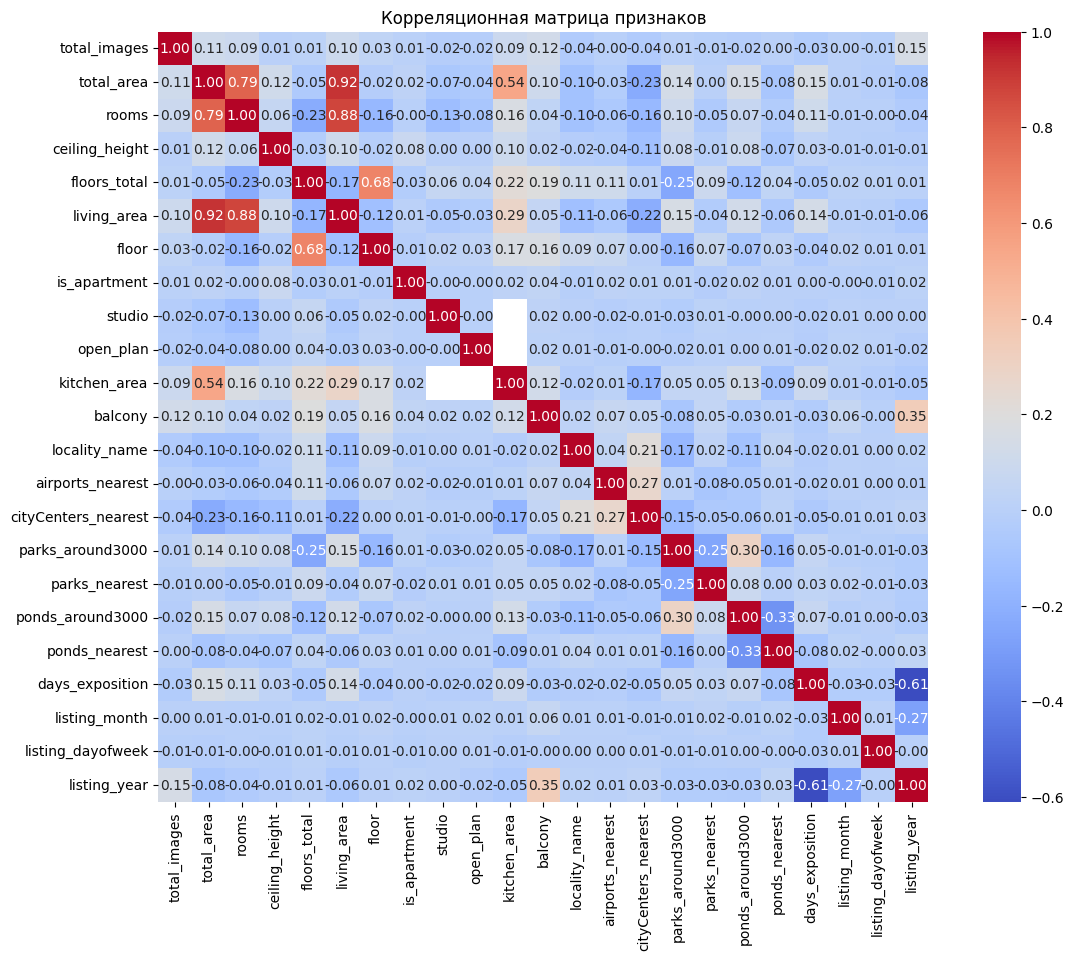

KeyError: 'last_price'

In [10]:
# 1. Убедимся, что DataFrame 'df' загружен (раскомментируйте и запустите, если нужно)
# df = pd.read_csv('/content/drive/MyDrive/data/real_estate_data.csv', sep='\t')

# 2. Подготовка данных для модели
X = df.drop(columns=['last_price'])
y = df['last_price']

# Кодирование булевых признаков в 0/1 (если они еще не преобразованы)
X['is_apartment'] = X['is_apartment'].astype(int)
X['studio'] = X['studio'].astype(int)
X['open_plan'] = X['open_plan'].astype(int)

# Оставляем только числовые столбцы для корреляции
X_numeric = X.select_dtypes(include=['number'])

# 3. Построение корреляционной матрицы
correlation_matrix = X_numeric.corr()

# Визуализация heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица признаков')
plt.show()

# Топ признаков по корреляции с ценой
price_correlation = correlation_matrix['last_price'].abs().sort_values(ascending=False)
print("\nТоп признаков по абсолютной корреляции с ценой:")
print(price_correlation.head(10))

In [11]:
# Убедимся, что у нас есть DataFrame X (если вы называли его иначе, замените X на ваше название)
# X = df.drop(columns=['last_price']).select_dtypes(include=[np.number])

print("=== ПРОВЕРКА НА НЕЧИСЛОВЫЕ ЗНАЧЕНИЯ ===")
for col in selected_features:
    # Проверяем тип данных в каждой ячейке колонки
    non_numeric = X[col][X[col].apply(type) != str]

    # Если в колонке есть значения, которые не являются строками (значит, это числа или NaN)
    # Мы ищем именно строки, которые не смогли преобразоваться в числа
    # Но проще проверить, есть ли в колонке тип object, который не является NaN
    if X[col].dtype == 'object':
        print(f"\n{col}: колонка имеет тип 'object'. Проверьте её содержимое.")
    else:
        print(f"{col}: OK (тип {X[col].dtype})")

print("\nПроверка завершена!")

=== ПРОВЕРКА НА НЕЧИСЛОВЫЕ ЗНАЧЕНИЯ ===


NameError: name 'selected_features' is not defined

NameError: name 'selected_features' is not defined

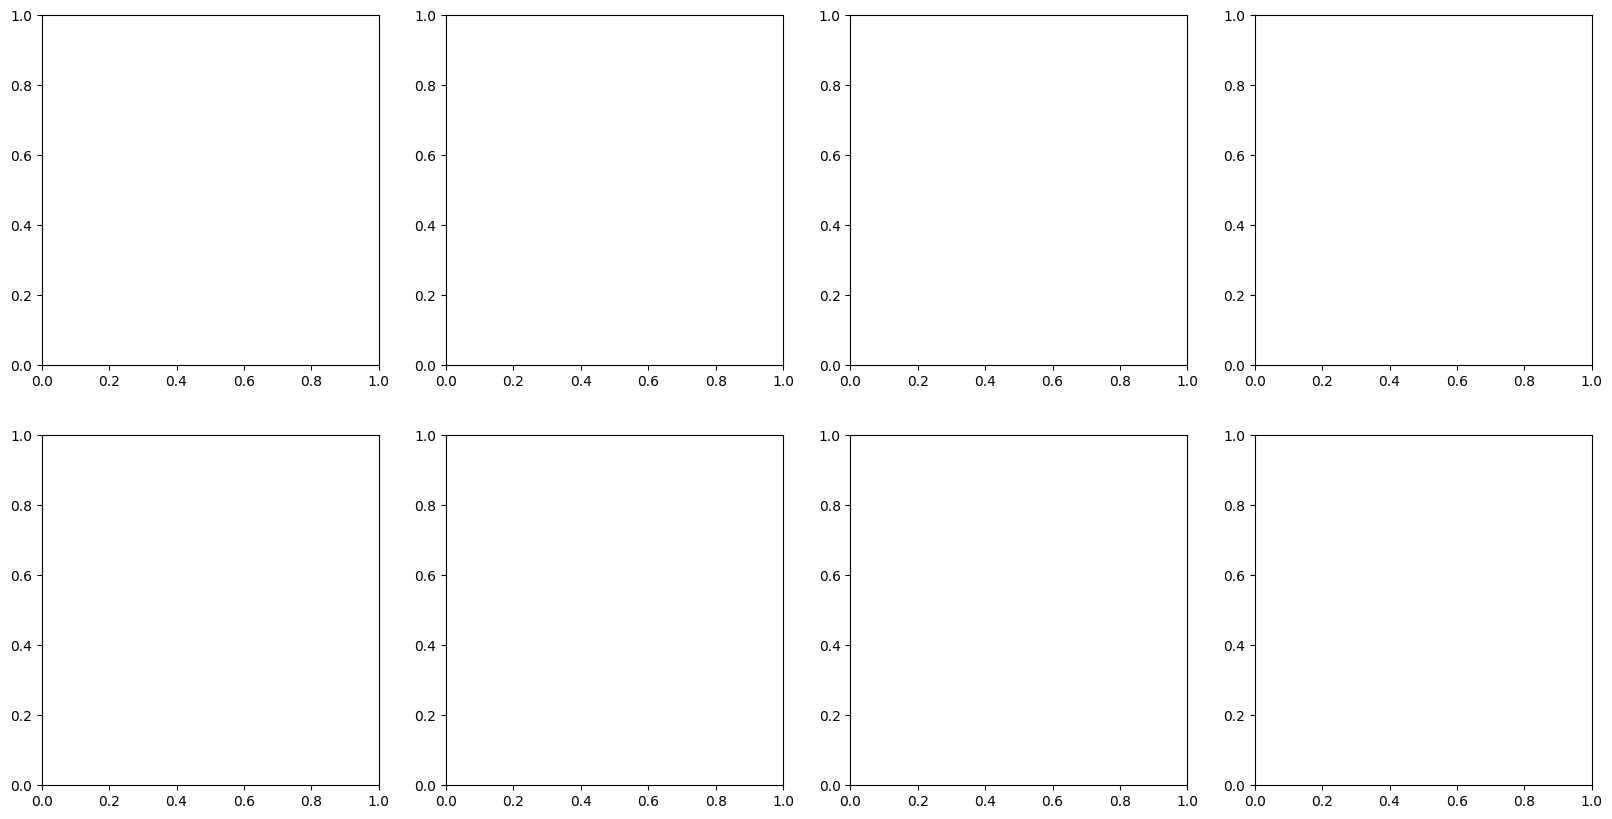

In [14]:
# Boxplots для всех отобранных признаков
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(selected_features):
    ax = axes[i]
    sns.boxplot(y=X_sel[col], ax=ax, color='skyblue')
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')

    # Добавим подписи квартилей
    Q1 = X_sel[col].quantile(0.25)
    Q2 = X_sel[col].quantile(0.50)
    Q3 = X_sel[col].quantile(0.75)
    ax.axhline(Q1, color='green', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axhline(Q2, color='red', linestyle='-', alpha=0.7, linewidth=1)
    ax.axhline(Q3, color='green', linestyle='--', alpha=0.5, linewidth=0.8)

    # Подписи квартилей
    ax.text(0.65, Q1, f'Q1={Q1:.1f}', fontsize=8, color='green')
    ax.text(0.65, Q2, f'Q2={Q2:.1f}', fontsize=8, color='red', fontweight='bold')
    ax.text(0.65, Q3, f'Q3={Q3:.1f}', fontsize=8, color='green')

    # Асимметрия (skewness)
    skew_val = X_sel[col].skew()
    ax.text(0.05, 0.95, f'skew={skew_val:.2f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Убираем пустые подграфики
for j in range(len(selected_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots отобранных признаков (с квартилями и асимметрией)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Числовые метрики асимметрии и эксцесса
print("\n=== АСИММЕТРИЯ (skewness) И ЭКСЦЕСС (kurtosis) ===")
print(f"{'Признак':<22} {'Skew':>8} {'Kurt':>8} {'Интерпретация':<25}")
print("=" * 70)
for col in selected_features:
    skew_val = X_sel[col].skew()
    kurt_val = X_sel[col].kurtosis()

    # Интерпретация асимметрии
    if abs(skew_val) < 0.5:
        interp = "≈ симметрично"
    elif skew_val > 0:
        interp = f"правосторонняя (хвост →)"
    else:
        interp = f"левосторонняя (← хвост)"

    print(f"{col:<22} {skew_val:>8.2f} {kurt_val:>8.2f} {interp:<25}")

In [13]:
# Гистограммы с Q-Q plots "ДО" преобразования
fig, axes = plt.subplots(len(selected_features), 2, figsize=(14, 4 * len(selected_features)))

for i, col in enumerate(selected_features):
    # Гистограмма
    axes[i, 0].hist(X_sel[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'{col} — ДО преобразования', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Частота')

    # Добавим skewness на график
    skew_val = X_sel[col].skew()
    axes[i, 0].text(0.95, 0.95, f'skew={skew_val:.2f}',
                    transform=axes[i, 0].transAxes, fontsize=10,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

    # Q-Q plot
    stats.probplot(X_sel[col], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'{col} — Q-Q plot', fontweight='bold')

plt.tight_layout()
plt.suptitle('Распределение признаков "ДО" преобразования',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

NameError: name 'selected_features' is not defined

In [15]:
from scipy import stats

# Функция подбора лучшего преобразования
def find_best_transform(series, name):
    """Подбирает лучшее преобразование по критерию близости к нормальности"""
    results = {}

    # Исходное
    results['Исходное'] = series.skew()

    # Log1p (для положительных значений)
    if (series > 0).all():
        results['log1p(x)'] = np.log1p(series).skew()

    # Sqrt (для положительных)
    if (series > 0).all():
        results['sqrt(x)'] = np.sqrt(series).skew()

    # Box-Cox (только строго положительные)
    if (series > 0).all() and (series != 0).all():
        try:
            transformed, lambda_val = stats.boxcox(series.dropna())
            results[f'Box-Cox (λ={lambda_val:.2f})'] = pd.Series(transformed).skew()
        except:
            pass

    # Yeo-Johnson (работает с любыми значениями)
    try:
        transformed, lambda_val = stats.yeojohnson(series.dropna())
        results[f'Yeo-Johnson (λ={lambda_val:.2f})'] = pd.Series(transformed).skew()

    # Reciprocal (1/x) — для правосторонних
    if (series > 0).all():
        results['1/x'] = (1/series).skew()

    # Находим лучшее (ближайшее к 0)
    best = min(results.items(), key=lambda x: abs(x[1]))
    return results, best

# Применяем ко всем отобранным признакам
print("=== ПОДБОР ЛУЧШЕГО ПРЕОБРАЗОВАНИЯ ===")
print(f"{'Признак':<22} {'Исходный skew':>14} {'Лучшее преобр.':<22} {'Новый skew':>12}")
print("=" * 75)

best_transforms = {}
for col in selected_features:
    results, best = find_best_transform(X_sel[col].dropna(), col)
    best_transforms[col] = best[0]
    print(f"{col:<22} {results['Исходное']:>14.2f} {best[0]:<22} {best[1]:>12.2f}")

SyntaxError: expected 'except' or 'finally' block (1381924645.py, line 33)

🔹 Порог для топ-10% по общей площади: 89.60 кв.м.
🔹 Количество объектов в топ-10%: 2280 из 22777

📊 Статистика для топ-10% самых больших объектов:


,total_area,last_price,rooms,cityCenters_nearest
count,2280.000000,2.280000e+03,2280.000000,2146.000000
mean,111.905732,1.344817e+07,3.451316,9881.637931
std,20.175807,6.080939e+06,0.894770,7979.053125
min,89.600000,1.450000e+06,0.000000,181.000000
25%,96.000000,9.200000e+06,3.000000,4378.250000
50%,105.700000,1.210000e+07,3.000000,7692.000000
75%,122.000000,1.600000e+07,4.000000,13355.000000
max,170.000000,3.600000e+07,8.000000,52895.000000


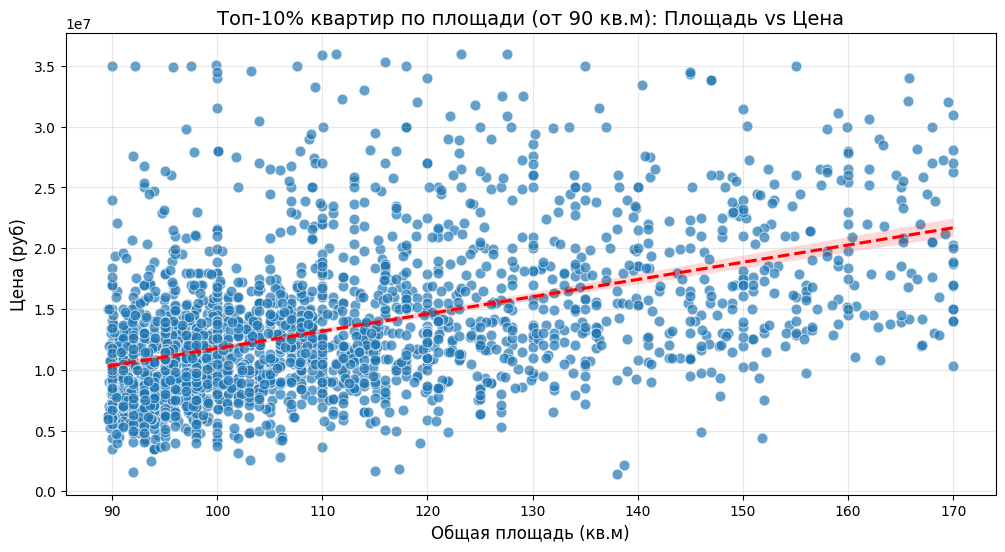


👁️ Топ-20 самых больших объектов (для визуальной проверки на аномалии):


,total_area,last_price,rooms,cityCenters_nearest
15647,170.0,20000000.0,5,11786.0
13224,170.0,16900000.0,6,5579.0
869,170.0,10335000.0,5,15247.0
7799,170.0,14000000.0,5,NaN
3378,170.0,31000000.0,4,5780.0
13729,170.0,20300000.0,3,4975.0
15073,170.0,15000000.0,5,7208.0
18992,170.0,15000000.0,5,5691.0
9574,170.0,18700000.0,4,2564.0
20542,170.0,18900000.0,3,13268.0


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Находим порог для топ-10% по общей площади
threshold_90 = df['total_area'].quantile(0.90)
print(f"🔹 Порог для топ-10% по общей площади: {threshold_90:.2f} кв.м.")

# 2. Фильтруем датасет
top_10_area = df[df['total_area'] >= threshold_90].copy()
print(f"🔹 Количество объектов в топ-10%: {len(top_10_area)} из {len(df)}")

# 3. Описательная статистика для топ-10% (смотрим на разброс цен и комнат)
print("\n📊 Статистика для топ-10% самых больших объектов:")
cols_to_show = ['total_area', 'last_price', 'rooms', 'cityCenters_nearest']
display(top_10_area[cols_to_show].describe())

# 4. Визуализация: Площадь vs Цена для топ-10%
plt.figure(figsize=(12, 6))
sns.scatterplot(data=top_10_area, x='total_area', y='last_price', alpha=0.7, s=60)

# Добавим линию тренда для наглядности
sns.regplot(data=top_10_area, x='total_area', y='last_price', scatter=False, color='red', line_kws={'linestyle':'--'})

plt.title(f'Топ-10% квартир по площади (от {threshold_90:.0f} кв.м): Площадь vs Цена', fontsize=14)
plt.xlabel('Общая площадь (кв.м)', fontsize=12)
plt.ylabel('Цена (руб)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 5. Выводим сами строки, отсортированные по убыванию площади, чтобы глазами найти аномалии
print("\n👁️ Топ-20 самых больших объектов (для визуальной проверки на аномалии):")
display(top_10_area.sort_values(by='total_area', ascending=False).head(20)[['total_area', 'last_price', 'rooms', 'cityCenters_nearest']])

In [17]:
from sklearn.model_selection import train_test_split

# Подготовка данных для модели
X = df.drop(columns=['last_price'])
y = df['last_price']

# Кодирование булевых признаков в 0/1 (на случай, если они еще в формате bool)
X['is_apartment'] = X['is_apartment'].astype(int)
X['studio'] = X['studio'].astype(int)
X['open_plan'] = X['open_plan'].astype(int)

# Оставляем только числовые столбцы
X = X.select_dtypes(include=['number'])

# Разделение на обучающую и тестовую выборки (80% на обучение, 20% на тест)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Количество признаков: {X.shape[1]}")
print()
print(f"Тренировочная выборка (train): {X_train.shape[0]} строк")
print(f"Тестовая выборка (test): {X_test.shape[0]} строк")
print()
print(f"Размер X_train: {X_train.shape}")
print(f"Размер X_test: {X_test.shape}")
print(f"Размер y_train: {y_train.shape}")
print(f"Размер y_test: {y_test.shape}")
print()
print(f"Процент данных для прогнозирования: {len(X_test)/len(df)*100:.1f}%")


Количество признаков: 23

Тренировочная выборка (train): 18221 строк
Тестовая выборка (test): 4556 строк

Размер X_train: (18221, 23)
Размер X_test: (4556, 23)
Размер y_train: (18221,)
Размер y_test: (4556,)

Процент данных для прогнозирования: 20.0%


In [18]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import time

# Попробуем импортировать XGBoost и LightGBM (если установлены)
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost не установлен. Установите: pip install xgboost")

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("LightGBM не установлен. Установите: pip install lightgbm")

# === ОПРЕДЕЛЯЕМ МОДЕЛИ ===
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=1.0, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'SVR (RBF)': SVR(kernel='rbf', C=10, epsilon=0.1),
}

# Добавляем XGBoost и LightGBM, если они установлены
if HAS_XGB:
    models['XGBoost'] = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
if HAS_LGBM:
    models['LightGBM'] = LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)

# === МАСШТАБИРОВАНИЕ для линейных моделей и SVR ===
# Линейные модели и SVR чувствительны к масштабу признаков
models_scaled = {
    'Linear Regression (Scaled)': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge (Scaled)': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso (Scaled)': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=1.0, max_iter=10000))]),
    'ElasticNet (Scaled)': Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))]),
    'SVR (Scaled)': Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf', C=10, epsilon=0.1))]),
    'KNN (Scaled)': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=5))]),
}

models.update(models_scaled)

print(f"Всего моделей для сравнения: {len(models)}")
print("Модели:", list(models.keys()))

Всего моделей для сравнения: 17
Модели: ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)', 'ElasticNet', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'KNN (k=5)', 'SVR (RBF)', 'XGBoost', 'LightGBM', 'Linear Regression (Scaled)', 'Ridge (Scaled)', 'Lasso (Scaled)', 'ElasticNet (Scaled)', 'SVR (Scaled)', 'KNN (Scaled)']


In [19]:
# Создаем DataFrame с важными признаками
important_features = ['total_area', 'cityCenters_nearest', 'kitchen_area',
                      'airports_nearest', 'floors_total']

X_important = df[important_features].copy()

# Проверяем наличие NaN
print("=== Проверка на NaN в важных признаках ===\n")
nan_counts = X_important.isnull().sum()
print(nan_counts)
print(f"\nОбщее количество NaN: {X_important.isnull().sum().sum()}")
print(f"Процент пропущенных значений: {X_important.isnull().sum().sum() / (len(X_important) * len(important_features)) * 100:.2f}%")

# Детальная информация по каждому признаку
print("\n=== Детальная информация ===")
for col in important_features:
    nan_count = X_important[col].isnull().sum()
    if nan_count > 0:
        print(f"\n{col}:")
        print(f"  Пропущено: {nan_count} ({nan_count/len(X_important)*100:.2f}%)")
        print(f"  Тип данных: {X_important[col].dtype}")
        print(f"  Непропущенных: {X_important[col].notna().sum()}")
    else:
        print(f"{col}: OK (нет пропусков)")

=== Проверка на NaN в важных признаках ===

total_area                0
cityCenters_nearest    5166
kitchen_area           1996
airports_nearest       5186
floors_total             79
dtype: int64

Общее количество NaN: 12427
Процент пропущенных значений: 10.91%

=== Детальная информация ===
total_area: OK (нет пропусков)

cityCenters_nearest:
  Пропущено: 5166 (22.68%)
  Тип данных: float64
  Непропущенных: 17611

kitchen_area:
  Пропущено: 1996 (8.76%)
  Тип данных: float64
  Непропущенных: 20781

airports_nearest:
  Пропущено: 5186 (22.77%)
  Тип данных: float64
  Непропущенных: 17591

floors_total:
  Пропущено: 79 (0.35%)
  Тип данных: float64
  Непропущенных: 22698


In [20]:
# Заполняем пропуски медианой
print("=== Заполнение пропусков медианой ===")
print("До заполнения:")
print(df[['cityCenters_nearest', 'kitchen_area', 'airports_nearest', 'floors_total']].isnull().sum())

# Заполняем пропуски медианой
df['cityCenters_nearest'] = df['cityCenters_nearest'].fillna(df['cityCenters_nearest'].median())
df['kitchen_area'] = df['kitchen_area'].fillna(df['kitchen_area'].median())
df['airports_nearest'] = df['airports_nearest'].fillna(df['airports_nearest'].median())
df['floors_total'] = df['floors_total'].fillna(df['floors_total'].median())

print("\nПосле заполнения:")
print(df[['cityCenters_nearest', 'kitchen_area', 'airports_nearest', 'floors_total']].isnull().sum())

print("\n=== Значения медиан ===")
print(f"cityCenters_nearest: {df['cityCenters_nearest'].median():.2f} м")
print(f"kitchen_area: {df['kitchen_area'].median():.2f} м²")
print(f"airports_nearest: {df['airports_nearest'].median():.2f} м")
print(f"floors_total: {df['floors_total'].median():.0f} этажей")

# Проверяем, что пропусков больше нет
print("\n=== Проверка пропусков во всех важных признаках ===")
important_cols = ['total_area', 'cityCenters_nearest', 'kitchen_area',
                  'airports_nearest', 'floors_total']
print(df[important_cols].isnull().sum())
print(f"\nОбщее количество пропусков: {df[important_cols].isnull().sum().sum()}")

=== Заполнение пропусков медианой ===
До заполнения:
cityCenters_nearest    5166
kitchen_area           1996
airports_nearest       5186
floors_total             79
dtype: int64

После заполнения:
cityCenters_nearest    0
kitchen_area           0
airports_nearest       0
floors_total           0
dtype: int64

=== Значения медиан ===
cityCenters_nearest: 13222.00 м
kitchen_area: 9.00 м²
airports_nearest: 26886.00 м
floors_total: 9 этажей

=== Проверка пропусков во всех важных признаках ===
total_area             0
cityCenters_nearest    0
kitchen_area           0
airports_nearest       0
floors_total           0
dtype: int64

Общее количество пропусков: 0


In [21]:
# Удаление выбросов из целевой переменной
Q1 = df['last_price'].quantile(0.01)
Q3 = df['last_price'].quantile(0.99)
IQR = Q3 - Q1

print(f"Q1 (1%): {Q1:,.0f}")
print(f"Q3 (99%): {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"Нижняя граница: {Q1 - 1.5 * IQR:,.0f}")
print(f"Верхняя граница: {Q3 + 1.5 * IQR:,.0f}")

# Удаляем выбросы
df = df[(df['last_price'] >= Q1 - 1.5 * IQR) & (df['last_price'] <= Q3 + 1.5 * IQR)]

print(f"\nПосле удаления выбросов:")
print(f"Осталось строк: {len(df)}")
print(f"Удалено строк: {len(df) - len(df)}")

Q1 (1%): 1,300,000
Q3 (99%): 23,000,000
IQR: 21,700,000
Нижняя граница: -31,250,000
Верхняя граница: 55,550,000

После удаления выбросов:
Осталось строк: 22777
Удалено строк: 0


In [22]:
# Правильный метод IQR
Q1 = df['last_price'].quantile(0.25)  # 25-й перцентиль
Q3 = df['last_price'].quantile(0.75)  # 75-й перцентиль
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25%): {Q1:,.0f}")
print(f"Q3 (75%): {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"Нижняя граница: {lower_bound:,.0f}")
print(f"Верхняя граница: {upper_bound:,.0f}")

# Удаление выбросов
initial_len = len(df)
df_filtered = df[(df['last_price'] >= lower_bound) & (df['last_price'] <= upper_bound)]

print(f"\nПосле удаления выбросов:")
print(f"Осталось строк: {len(df_filtered)}")
print(f"Удалено строк: {initial_len - len(df_filtered)}")

Q1 (25%): 3,490,000
Q3 (75%): 6,650,000
IQR: 3,160,000
Нижняя граница: -1,250,000
Верхняя граница: 11,390,000

После удаления выбросов:
Осталось строк: 21018
Удалено строк: 1759


In [23]:
# Заполняем ВСЕ NaN во всех числовых столбцах медианой
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Проверяем, что все NaN заполнены
print(f"Осталось NaN в df: {df.isna().sum().sum()}")

# Теперь создаём X и y
X = df.drop(columns=['last_price'])
y = df['last_price']

# Кодирование булевых признаков в 0/1
X['is_apartment'] = X['is_apartment'].astype(int)
X['studio'] = X['studio'].astype(int)
X['open_plan'] = X['open_plan'].astype(int)

# Оставляем только числовые столбцы
X = X.select_dtypes(include=[np.number])

# Проверяем, что в X нет NaN
print(f"Осталось NaN в X: {X.isna().sum().sum()}")

# Теперь можно обучать модели
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

Осталось NaN в df: 0
Осталось NaN в X: 0


In [24]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Создаём pipeline с импутером
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])

# Обучаем pipeline (импутер автоматически заполнит NaN)
pipeline.fit(X_train, y_train)
y_pred_lr = pipeline.predict(X_test)

In [25]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
import time

# Попробуем импортировать XGBoost и LightGBM
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost не установлен")

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("LightGBM не установлен")

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаём pipeline с импутером и скейлером
def create_pipeline(model, scale=False):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('regressor', model))
    return Pipeline(steps)

# Определяем все модели
models = {
    'Linear Regression': create_pipeline(LinearRegression(), scale=True),
    'Ridge (L2)': create_pipeline(Ridge(alpha=1.0), scale=True),
    'Lasso (L1)': create_pipeline(Lasso(alpha=1.0, max_iter=10000), scale=True),
    'ElasticNet': create_pipeline(ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000), scale=True),
    'Decision Tree': create_pipeline(DecisionTreeRegressor(max_depth=10, random_state=42), scale=False),
    'Random Forest': create_pipeline(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), scale=False),
    'Gradient Boosting': create_pipeline(GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42), scale=False),
    'KNN (k=5)': create_pipeline(KNeighborsRegressor(n_neighbors=5), scale=True),
    'SVR (RBF)': create_pipeline(SVR(kernel='rbf', C=10, epsilon=0.1), scale=True),
}

# Добавляем XGBoost и LightGBM, если установлены
if HAS_XGB:
    models['XGBoost'] = create_pipeline(XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1), scale=False)
if HAS_LGBM:
    models['LightGBM'] = create_pipeline(LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1), scale=False)

# Обучаем и оцениваем все модели
results = []

print("=" * 90)
print(f"{'Модель':<30} {'MAE':>15} {'RMSE':>15} {'R²':>10} {'Время (с)':>10}")
print("=" * 90)

for name, model in models.items():
    start_time = time.time()

    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        elapsed = time.time() - start_time

        results.append({
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Time': elapsed
        })

        print(f"{name:<30} {mae:>15,.0f} {rmse:>15,.0f} {r2:>10.4f} {elapsed:>10.2f}")
    except Exception as e:
        print(f"{name:<30} ОШИБКА: {str(e)[:50]}")

print("=" * 90)

# Сортируем по R²
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\n🏆 РЕЙТИНГ МОДЕЛЕЙ (по R²):")
print(results_df.to_string(index=False))

Модель                                     MAE            RMSE         R²  Время (с)
Linear Regression                    1,336,387       2,145,586     0.6932       0.06
Ridge (L2)                           1,336,342       2,145,569     0.6932       0.15
Lasso (L1)                           1,336,386       2,145,586     0.6932       0.24
ElasticNet                           1,363,684       2,320,255     0.6412       0.13
Decision Tree                        1,117,560       2,220,843     0.6713       0.39
Random Forest                          903,451       1,736,568     0.7990      22.79
Gradient Boosting                      914,222       1,721,636     0.8024       8.71
KNN (k=5)                            1,225,220       2,224,414     0.6702       0.96
SVR (RBF)                            2,398,111       4,035,018    -0.0852      27.08
XGBoost                                926,639       1,733,119     0.7998       0.43
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the ove

In [27]:
import joblib
from google.colab import drive

# Принудительно подключаем диск, чтобы точно знать, что он доступен
drive.mount('/content/drive', force_remount=True)

# Берем нашу модель Random Forest из словаря
best_model = models['Random Forest']

# Сохраняем её на Google Диск
joblib.dump(best_model, '/content/drive/MyDrive/rf_model.pkl')

print("✅ Модель успешно сохранена на Google Диск как 'rf_model.pkl'")

Mounted at /content/drive
✅ Модель успешно сохранена на Google Диск как 'rf_model.pkl'
